In [1]:
import illustris_python as il
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl
import h5py   
from Corrfunc.theory import xi
import time
from scipy.special import erf

In [2]:
tng_dir = "/cosma7/data/dp004/dc-zhan5/TNG/snap40/SubhaloFlag_all/mvir/ihalo"
tng_data = np.loadtxt(f"{tng_dir}/sfr-halomass_sum.txt")
mhalo_tng = tng_data[:,1]
pos_tng = tng_data[:,2:5]
sfr_tng = tng_data[:,5]


In [3]:
mask = mhalo_tng > 10
mhalo_tng = mhalo_tng[mask]
pos_tng = pos_tng[mask]
sfr_tng = sfr_tng[mask]



In [5]:
boxsize=205

In [6]:
rmin = 0.01
rmax = 3
nbins = 100
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1)

results_weighted = xi(boxsize, 2, rbins , pos_tng[:,0],pos_tng[:,1],pos_tng[:,2], 
             weights=10**sfr_tng,weight_type='pair_product',output_ravg=True)

In [7]:
basePath = "/cosma7/data/dp004/dc-zhan5/TNG300-3-Dark/snapshot"

In [8]:
fields = ['Coordinates']
dm_coords = il.snapshot.loadSubset(basePath,40,'dm',fields=fields)
dm_coords /= 1e3

In [9]:
len(dm_coords)

244140625

In [10]:
iend = int(1e2)

In [11]:
dm_coords_test = dm_coords[::iend]

In [12]:
len(dm_coords_test)

2441407

In [13]:
rmin = 0.01
rmax = 3
nbins = 100
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1)

In [14]:

start_time = time.time()
results_dm = xi(boxsize, 2, rbins , dm_coords_test[:,0],dm_coords_test[:,1],dm_coords_test[:,2],output_ravg=True)
end_time = time.time()
print(end_time-start_time)

3.3863494396209717


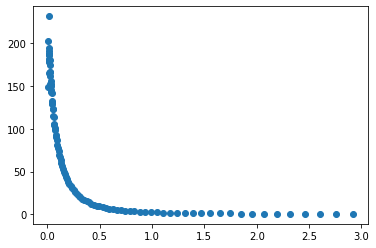

In [15]:
plt.scatter(results_dm["ravg"], results_dm["xi"], label="TNG DM")


In [31]:
def lognormal_cf(rbins, xi_results, sigma, R,bias=1):
    #dr = 0.00003
#     Nr = int( rmax / dr )
  
#     r_list = np.array([ dr * (i+1) for i in range(Nr) ])
    
    d = 2*R
    x = np.log10(rbins / d) / (np.sqrt(2) * sigma)
    fr = 1 - 0.5 * (1.0 + erf(x))
    if sigma == 0:
        xi_d = xi_results*bias**2
    else:
        xi_d = (1 - fr) * (xi_results*bias**2 + 1) - 1

    return xi_d

In [29]:
cf_list = lognormal_cf(results_dm["ravg"], results_dm["xi"], bias=2, sigma=0.17, R=0.37)


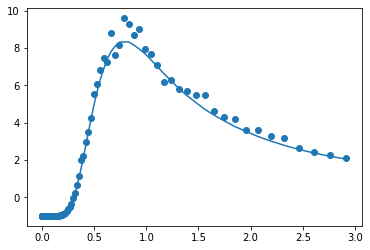

In [30]:

plt.plot(results_dm["ravg"], cf_list)
plt.scatter(results_weighted["ravg"], results_weighted["xi"], label="TNG all (weighted)")
